This notebook provides examples on how to interact with your energy transfer and turbulence flow analysis data via the "interface" module. 

In [2]:
from energy_transfer_interface import *

# The Simulation class

Simulation class objects contain all the relevant information of your "AthenaPK" simulations, including information about the input files, history files, aswell as methods for loading snapshots and analysis data for visualisation and plotting. 

## Define a simulation

To define a simulation object, you need to pass the path to your simulation directory (i.e. the directory that contains the .in file, as well as the snapshots and spectra / energy transfer files): 

In [3]:
s = Simulation("example_folder")
s 

Simulation directory: example_folder
Number of Snapshots: 2
Covered time: 2.0

## Initial information about your simulation

The simulation parameters (as specified in the input file) can be returned as follows: 

In [5]:
s.config

{'comment': {'problem': 'Hydro setup with constant density and pressure'},
 'job': {'problem_id': 'stochastic_B_field'},
 'parthenon/output1': {'file_type': 'hst', 'dt': 0.01},
 'parthenon/output2': {'file_type': 'hdf5',
  'variables': 'prim,acc',
  'dt': 1.0,
  'id': 'prim',
  'single_precision_output': 'true'},
 'parthenon/output3': {'file_type': 'rst', 'dt': 1.0, 'id': 'restart'},
 'problem/stochastic_B_field': {'rho0': 1.0,
  'p0': 1.0,
  'vx': 0.0,
  'vy': 0.0,
  'vz': 0.0,
  'kmax': 32.0,
  'B_rms': 1.0,
  'kI': 3.0,
  'n1': 4.0,
  'n2': 1.6666666666666667,
  'alpha': 1000.0,
  'helicity': 1.0},
 'refinement': {'type': 'maxdensity',
  'maxdensity_deref_below': 1.00005,
  'maxdensity_refine_above': 1.0001},
 'parthenon/mesh': {'refinement': 'none',
  'nghost': 3,
  'nx1': 32,
  'x1min': -3.141593,
  'x1max': 3.141593,
  'ix1_bc': 'periodic',
  'ox1_bc': 'periodic',
  'nx2': 32,
  'x2min': -3.141593,
  'x2max': 3.141593,
  'ix2_bc': 'periodic',
  'ox2_bc': 'periodic',
  'nx3': 32,


## The history file can be returned as a pandas dataframe object:

In [17]:
hst = s.history
hst 

/p/project1/coldcluster/lenard/energy-transfer-analysis/interface/energy_transfer_interface/analysis.py:389: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(hist_file, delim_whitespace=True, comment='#')


,time,dt,cycle,nbtotal,mass,1-mom,2-mom,3-mom,KE,tot-E,ME,relDivB,dlogME_dlogt
0,0.020545,0.020467,1,1,248.05,-2.641370e-16,-2.575320e-16,-3.421460e-17,0.040112,2480630.0,123.880,0.027476,-0.002431
1,0.041013,0.020426,2,1,248.05,2.045010e-16,-3.189520e-16,2.546630e-16,0.156006,2480630.0,123.672,0.026507,-0.004297
2,0.061439,0.020424,3,1,248.05,1.705650e-16,4.434250e-16,2.915540e-16,0.340853,2480630.0,123.403,0.025068,-0.007660
3,0.081863,0.020461,4,1,248.05,8.355810e-17,5.715370e-16,-4.047460e-17,0.587706,2480630.0,123.075,0.023385,-0.011937
4,0.102324,0.020558,5,1,248.05,-1.064420e-16,-1.223030e-15,-2.032610e-16,0.889243,2480630.0,122.691,0.021713,-0.016994
5,0.122882,0.020637,6,1,248.05,3.439630e-16,5.824470e-16,4.048410e-16,1.238310,2480630.0,122.255,0.020149,-0.022635
6,0.143519,0.020547,7,1,248.05,-6.612550e-16,-3.783710e-15,1.718410e-15,1.626120,2480630.0,121.775,0.018806,-0.028742
7,0.164066,0.020530,8,1,248.05,8.685000e-16,1.857730e-15,4.646620e-16,2.040610,2480630.0,121.260,0.017789,-0.035072
8,0.184596,0.020407,9,1,248.05,4.534130e-16,-2.646860e-15,2.212860e-16,2.474500,2480630.0,120.717,0.017130,-0.041430
9,0.205004,0.020326,10,1,248.05,-1.942730e-15,1.658100e-15,-9.461020e-16,2.917290,2480630.0,120.156,0.016845,-0.047793


## which makes plotting the history data super easy: 

Text(0, 0.5, 'Magnetic Energy')

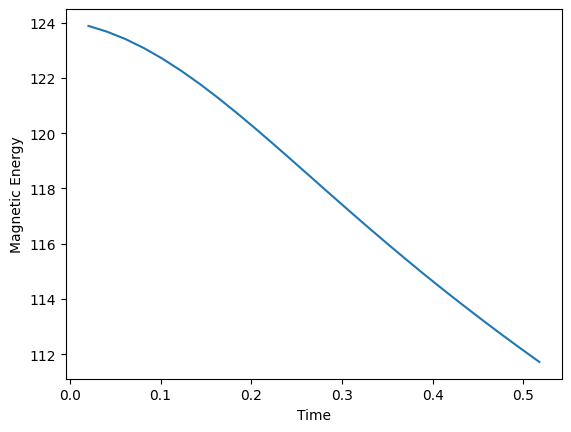

In [8]:
from matplotlib import pyplot as plt
plt.plot(hst["time"], hst["ME"])
plt.xlabel("Time")
plt.ylabel("Magnetic Energy")

# Snapshots

From the simulation object, a snapshot can be loaded by passing the time (in internal code units): 

In [16]:
snap = s.get_snapshot(0)

This loads the snapshot (.phdf file) whose time is closest to the value that was passed and creates a "SimSnap" object, which is just a wrapper for a yt dataset. To get the raw yt dataset object, simply do

In [12]:
snap.ds 

ParthenonDataset: /p/project1/coldcluster/lenard/energy-transfer-analysis/interface/example_folder/parthenon.prim.00000.phdf

## Plotting slices

The "SimSnap" object contains a simple method for plotting slices of snapshots: 


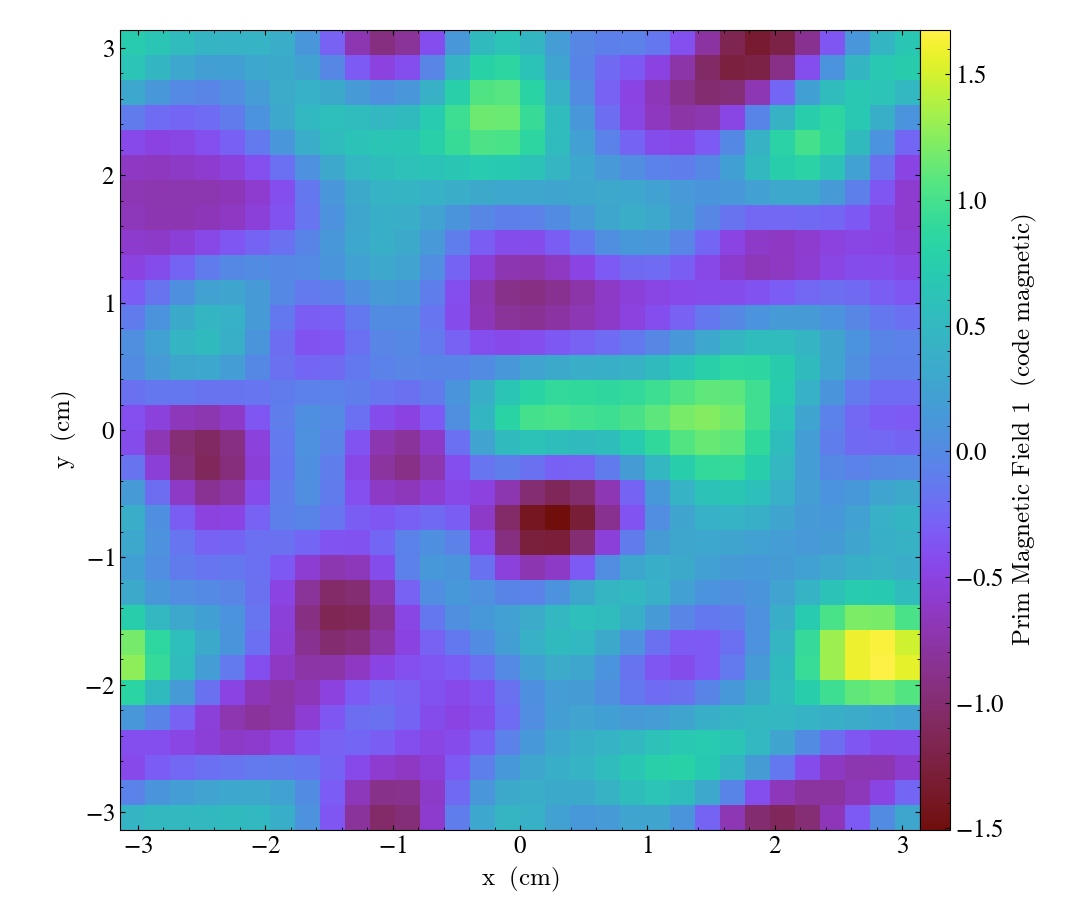

In [14]:
snap.plot_slice("Bx")

# Spectra

Working with spectra is done via the "energy_transfer_interface.analysis.Spectrum class. 
There are two ways of creating a Spectrum object. 

1) Given a single spectrum file, use the "io_utils.get_spectrum" function. 
2) Create a simulation class and its "get_spectrum" function to load the spectrum. 

## 1. Creating a spectrum from a standalone file



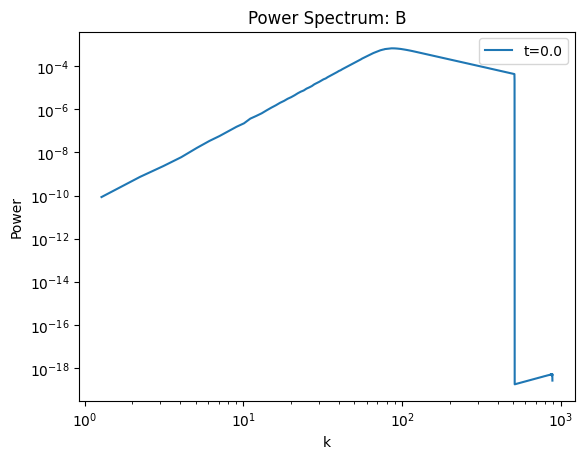

In [10]:
get_spectrum("example_spectrum.hdf5", "B").plot()